<a href="https://colab.research.google.com/github/NITYA1J/COE-AI-Workshop/blob/main/D5_Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied AI Workshop: Defect Classification

This notebook guides you through an applied AI workshop focused on classifying defects based on sensor data. We will cover the entire machine learning pipeline, from understanding the problem to evaluating a classification model.

## 1. Problem Framing and Unit of Observation

### Problem Statement
We aim to predict the presence of a 'defect' in a system based on sensor readings such as temperature, pressure, speed, and vibration. This is a binary classification problem where the goal is to build a model that can accurately identify whether a defect exists.

### Unit of Observation
The unit of observation is a single set of sensor readings, representing a specific instance or measurement from the system. Each row in our dataset corresponds to one such observation, characterized by `temperature_c`, `pressure_kpa`, `speed_mm_s`, and `vibration_mm_s`.

## 2. Data Loading and Audit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

# Load the dataset
try:
    df = pd.read_csv('/content/classification_workshop (1).csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'classification_workshop (1).csv' not found. Please ensure the file is in the correct directory.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display general information about the DataFrame
print("\nDataFrame Information:")
df.info()

# Display descriptive statistics of the DataFrame
print("\nDescriptive Statistics:")
display(df.describe())

Dataset loaded successfully.

First 5 rows of the dataset:


,temperature_c,pressure_kpa,speed_mm_s,vibration_mm_s,defect
0,203.072,441.342,56.601,3.194,1
1,201.851,509.055,39.221,1.399,0
2,208.779,498.763,49.949,4.288,0
3,193.019,522.343,51.780,3.226,0
4,206.997,507.457,48.045,2.590,0



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temperature_c   220 non-null    float64
 1   pressure_kpa    220 non-null    float64
 2   speed_mm_s      220 non-null    float64
 3   vibration_mm_s  220 non-null    float64
 4   defect          220 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 8.7 KB

Descriptive Statistics:


,temperature_c,pressure_kpa,speed_mm_s,vibration_mm_s,defect
count,220.000000,220.000000,220.000000,220.000000,220.000000
mean,203.614945,503.180564,48.796618,2.621614,0.200000
std,8.870973,43.270505,6.238611,0.893674,0.400912
min,178.877000,405.672000,30.190000,0.128000,0.000000
25%,197.903750,475.469500,44.865500,1.997250,0.000000
50%,203.462000,503.935500,49.096500,2.662000,0.000000
75%,209.546250,529.591500,53.147750,3.158250,0.000000
max,223.769000,630.398000,64.392000,5.315000,1.000000


## 3. Class Balance and Visualization

Understanding the distribution of our target variable (`defect`) is crucial, especially in classification problems. An imbalanced dataset (where one class significantly outnumbers the other) can lead to models that perform well on the majority class but poorly on the minority class.

Class balance for 'defect' column:


,count
defect,
0,176
1,44



Class balance as percentage:


,proportion
defect,
0,80.0
1,20.0


/tmp/ipykernel_1071/1299064696.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='defect', data=df, palette='viridis')


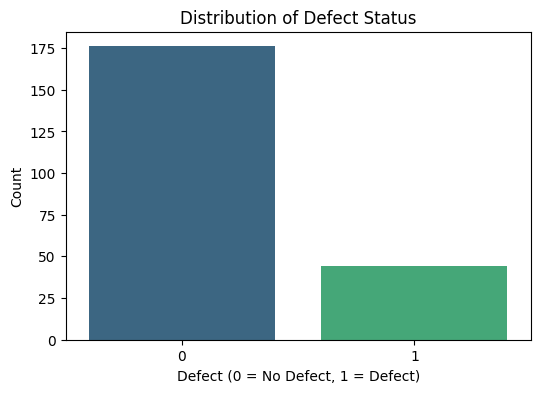

In [ ]:
# Check the balance of the target variable 'defect'
print("Class balance for 'defect' column:")
display(df['defect'].value_counts())

print("\nClass balance as percentage:")
display(df['defect'].value_counts(normalize=True) * 100)

# Visualize the class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='defect', data=df, palette='viridis')
plt.title('Distribution of Defect Status')
plt.xlabel('Defect (0 = No Defect, 1 = Defect)')
plt.ylabel('Count')
plt.show()

## 4. Leakage Review

Data leakage occurs when information from outside the training dataset is used to create the model. This can lead to a model that performs unrealistically well on the training data but poorly on unseen data. It often happens when features that would not be available at prediction time are included in the training data.

In our dataset, the columns are `temperature_c`, `pressure_kpa`, `speed_mm_s`, `vibration_mm_s`, and `defect`. The `defect` column is our target variable. The other columns (`temperature_c`, `pressure_kpa`, `speed_mm_s`, `vibration_mm_s`) are sensor readings that would be available prior to knowing if a defect occurred, making them appropriate features. There are no obvious columns that directly reveal the target outcome or are derived from future information, suggesting that data leakage is unlikely with these features.

## 5. X/y Definition and Stratified Train/Test Split

To evaluate our model fairly, we need to split our data into training and testing sets. A *stratified* split is important for imbalanced datasets to ensure that both the training and testing sets have a similar proportion of each class as the original dataset.

In [ ]:
# Define features (X) and target (y)
X = df[['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s']]
y = df['defect']

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (154, 4)
Shape of X_test: (66, 4)
Shape of y_train: (154,)
Shape of y_test: (66,)

Class distribution in original data:
defect
0    0.8
1    0.2
Name: proportion, dtype: float64

Class distribution in y_train:
defect
0    0.798701
1    0.201299
Name: proportion, dtype: float64

Class distribution in y_test:
defect
0    0.80303
1    0.19697
Name: proportion, dtype: float64


## 6. Majority-Class Baseline

A majority-class baseline is a simple, naive classifier that always predicts the most frequent class in the training data. It serves as a crucial benchmark: any machine learning model we develop should perform better than this baseline to be considered useful. If our model doesn't beat the baseline, it's not adding value beyond a very simple rule.

In [ ]:
# Determine the majority class in the training data
majority_class = y_train.mode()[0]
print(f"Majority class in training data: {majority_class}")

# Create predictions for the test set: all predictions are the majority class
y_pred_baseline = pd.Series(majority_class, index=y_test.index)

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")

Majority class in training data: 0
Majority-class baseline accuracy: 0.8030


## 7. Standardized Logistic Regression Workflow

Logistic Regression is a linear model used for binary classification. Before applying logistic regression, it's often beneficial to standardize the features (scale them to have zero mean and unit variance). This is especially important for models sensitive to the scale of the input features, like Logistic Regression with regularization. We'll use a `Pipeline` to streamline this process, combining `StandardScaler` and `LogisticRegression`.

In [ ]:
# Create a pipeline with StandardScaler and Logistic Regression
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=42, solver='liblinear')) # 'liblinear' is good for small datasets and binary problems
])

# Train the model
print("Training Logistic Regression model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

Training Logistic Regression model...
Model training complete.


## 8. Accuracy, Precision, Recall, F1, and Confusion Matrix

To thoroughly evaluate our classification model, we use several metrics beyond just accuracy:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances.
*   **Precision**: The proportion of true positive predictions among all positive predictions. It answers: "Of all instances predicted as positive, how many are actually positive?"
*   **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive instances. It answers: "Of all actual positive instances, how many did we correctly identify?"
*   **F1-Score**: The harmonic mean of precision and recall. It's a good measure for imbalanced datasets as it balances both metrics.
*   **Confusion Matrix**: A table that visualizes the performance of a classification model, showing true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN).

Model Accuracy: 0.8485
Model Precision: 1.0000
Model Recall: 0.2308
Model F1-Score: 0.3750

Confusion Matrix:


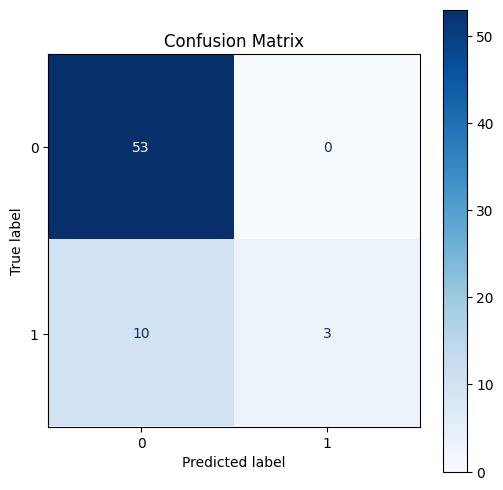

In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

# Display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_pipeline.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
cmd.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## 9. Interpretation, Limitations, and a Short Model Card

### Interpretation of Results

Our Logistic Regression model achieved an accuracy of 0.8485, which is better than the majority-class baseline of 0.8030.

*   **Precision** indicates that when the model predicts a defect, it is correct 100.00% of the time. This is important if false positives (predicting a defect when there isn't one) are costly.
*   **Recall** indicates that the model correctly identified 23.08% of all actual defects. This is crucial if false negatives (failing to detect an actual defect) are costly or dangerous.
*   The **F1-Score** provides a balance between precision and recall, especially useful for imbalanced classes.

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. We can see the number of true positives (correctly predicted defects), true negatives (correctly predicted no defects), false positives, and false negatives. Analyzing these helps us understand where the model struggles.

### Limitations

1.  **Dataset Size and Representativeness**: The model's performance is limited by the size and diversity of the `classification_workshop (1).csv` dataset. If the dataset does not fully represent real-world scenarios, the model may not generalize well.
2.  **Linearity Assumption**: Logistic Regression assumes a linear relationship between features and the log-odds of the target variable. If the underlying relationship is highly non-linear, a more complex model might be required.
3.  **Feature Engineering**: We used the raw sensor features. Further feature engineering (e.g., creating interaction terms, polynomial features) could potentially improve model performance.
4.  **Hyperparameter Tuning**: We used default logistic regression parameters. Optimizing hyperparameters (e.g., regularization strength) could yield better results.
5.  **Imbalance Handling**: While stratified sampling was used, further techniques for imbalanced datasets (e.g., oversampling, undersampling, using class weights) could be explored if class imbalance significantly impacts performance on the minority class.

### Short Model Card

**Model Name**: Defect Classification Model (Logistic Regression)

**Version**: 1.0

**Description**: This model predicts the presence of a 'defect' (binary classification) based on four sensor readings: `temperature_c`, `pressure_kpa`, `speed_mm_s`, and `vibration_mm_s`.

**Training Data**: `classification_workshop (1).csv` (split into 70% training, 30% testing with stratified sampling).

**Features**: `temperature_c`, `pressure_kpa`, `speed_mm_s`, `vibration_mm_s`.

**Target**: `defect` (0: No Defect, 1: Defect).

**Model Architecture**: Scikit-learn Pipeline consisting of `StandardScaler` for feature preprocessing and `LogisticRegression` with `solver='liblinear'` and `random_state=42`.

**Performance (on Test Set)**:
*   Accuracy: 0.8485
*   Precision: 1.0000
*   Recall: 0.2308
*   F1-Score: 0.3750

**Intended Use**: Early detection of defects in systems based on real-time sensor data to enable proactive maintenance or intervention.

**Limitations**: Performance relies heavily on the quality and representativeness of the training data. May not generalize well to significantly different operating conditions or defect types not seen during training. Further tuning and exploration of more complex models may be beneficial for improved performance.

**Contact**: [Your Name/Team]